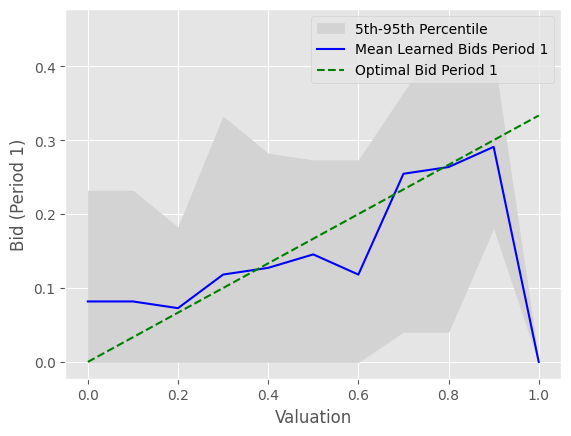

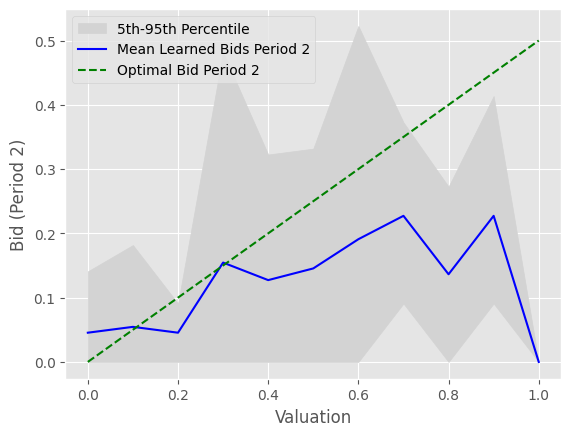

In [95]:
import numpy as np
import matplotlib.pyplot as plt

class QLearnerTwoPeriod:
    def __init__(self, granularity, alpha=0.1, gamma=1.0, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.99995):
        self.q_table1 = np.ones((granularity, granularity))
        self.q_table2 = np.ones((granularity, granularity))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.granularity = granularity

    def choose_action(self, state, period):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.granularity)
        if period == 1:
            return np.argmax(self.q_table1[state])
        else:
            return np.argmax(self.q_table2[state])

    def update_q1(self, state, action, reward, next_state, lost_in_period1):
        if lost_in_period1:
            max_q2 = np.max(self.q_table2[next_state])  # Use Q2 if the player loses in period 1
        else:
            max_q2 = 0  # No reward from period 2 if won in period 1
        td_target = reward + self.gamma * max_q2
        self.q_table1[state, action] += self.alpha * (td_target - self.q_table1[state, action])

    def update_q2(self, state, action, reward):
        td_target = reward
        self.q_table2[state, action] += self.alpha * (td_target - self.q_table2[state, action])

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

def auction_round(qlearners, valuations, period, granularity, winners):
    bids = [qlearners[i].choose_action(valuations[i], period) for i in range(len(qlearners))]
    sorted_bids = np.argsort(bids)[::-1]
    
    winner = None
    for bidder in sorted_bids:
        if winners[bidder] == 0:  # Unit demand constraint: bidder can only win once
            winner = bidder
            break
    
    return winner, bids[winner] if winner is not None else None

def simulate_two_period_auction(num_rounds=100000, granularity=20):
    qlearners = [QLearnerTwoPeriod(granularity) for _ in range(3)]
    
    for _ in range(num_rounds):
        valuations = [int(np.random.uniform(0, 1) * (granularity - 1)) for _ in range(3)]
        winners = [0, 0, 0]  # To track if a player has already won
        
        # Period 1
        winner, winning_bid = auction_round(qlearners, valuations, period=1, granularity=granularity, winners=winners)
        
        if winner is not None:
            winners[winner] = 1
            reward_winner = valuations[winner] / (granularity - 1) - winning_bid / granularity
            reward_losers = 0
            
            for i in range(3):
                lost_in_period1 = (i != winner)  # Only those who lost in period 1 look up Q2
                qlearners[i].update_q1(valuations[i], qlearners[i].choose_action(valuations[i], 1), reward_winner if i == winner else reward_losers, valuations[i], lost_in_period1)
        
        # Period 2
        remaining_players = [i for i in range(3) if winners[i] == 0]
        if len(remaining_players) > 0:
            remaining_valuations = [valuations[i] for i in remaining_players]
            remaining_qlearners = [qlearners[i] for i in remaining_players]
            winner, winning_bid = auction_round(remaining_qlearners, remaining_valuations, period=2, granularity=granularity, winners=winners)
            
            if winner is not None:
                real_winner = remaining_players[winner]  # Map back to the original player
                reward_winner = remaining_valuations[winner] / (granularity - 1) - winning_bid / granularity
                reward_losers = 0
                
                for i in remaining_players:
                    qlearners[i].update_q2(valuations[i], qlearners[i].choose_action(valuations[i], 2), reward_winner if i == real_winner else reward_losers)
        
        for qlearner in qlearners:
            qlearner.decay_epsilon()
    
    return [qlearner.q_table1 for qlearner in qlearners], [qlearner.q_table2 for qlearners in qlearners]

def plot_mean_bids_with_bounds(q_tables, granularity, period):
    valuations = np.linspace(0, 1, granularity)
    
    # Collect bids over all Monte Carlo runs
    bids_per_run = []
    
    for q_tables_run in q_tables:
        bids = np.array([np.argmax(q_table, axis=1) / granularity for q_table in q_tables_run])
        bids_per_run.append(bids)

    # Stack bids for calculating statistics
    bids_per_run = np.stack(bids_per_run, axis=0)

    # Calculate mean, 5th, and 95th percentiles
    mean_bids = np.mean(bids_per_run, axis=0)
    bids_5th_percentile = np.percentile(bids_per_run, 5, axis=0)
    bids_95th_percentile = np.percentile(bids_per_run, 95, axis=0)

    plt.fill_between(valuations, bids_5th_percentile[0], bids_95th_percentile[0], color='lightgray', label='5th-95th Percentile')
    plt.plot(valuations, mean_bids[0], label=f'Mean Learned Bids Period {period}', color='blue')

    # Optimal bid formula
    N = 3  # Number of bidders
    K = 2  # Number of items
    k = period  # Current period
    optimal_bids = (N - K) / (N - k + 1) * valuations

    # Plot the optimal bid line
    plt.plot(valuations, optimal_bids, label=f'Optimal Bid Period {period}', linestyle='--', color='green')

    plt.xlabel('Valuation')
    plt.ylabel(f'Bid (Period {period})')
    plt.legend()
    plt.show()

def run_monte_carlo_simulation(num_runs=10, num_rounds=100000, granularity=21):
    q_tables1_all = []
    q_tables2_all = []
    
    for _ in range(num_runs):
        q_tables1, q_tables2 = simulate_two_period_auction(num_rounds=num_rounds, granularity=granularity)
        q_tables1_all.append(q_tables1)
        q_tables2_all.append(q_tables2)
    
    return q_tables1_all, q_tables2_all

# Perform Monte Carlo simulation and plot mean with bounds
granularity = 11
q_tables1_all, q_tables2_all = run_monte_carlo_simulation(granularity=granularity)
plot_mean_bids_with_bounds(q_tables1_all, granularity=granularity, period=1)
plot_mean_bids_with_bounds(q_tables2_all, granularity=granularity, period=2)